<a href="https://colab.research.google.com/github/NisargOza/NisargOza/blob/main/EEG_PD_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [15]:
import pandas as pd
import numpy as np
import random
import joblib
import traceback
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.metrics import (classification_report, confusion_matrix, roc_curve, auc,
                           f1_score, accuracy_score, precision_score, recall_score,
                           roc_auc_score)
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
import xgboost as xgb
import lightgbm as lgb
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')

# Set all random seeds
def set_seeds(seed=42):
    np.random.seed(seed)
    random.seed(seed)

set_seeds()

In [16]:
def load_and_preprocess_data(filepath):
    data = pd.read_csv(filepath)
    X = data[['findi_score', 'nsi_score']].copy()
    y = data['target'].copy()

    # Clean data
    X = X.replace([np.inf, -np.inf], np.nan)
    X = X.fillna(X.median())

    # Prioritized feature engineering focusing on FINDI and NSI
    feature_dict = {
        # Primary biomarkers (given higher importance)
        'findi_baseline': X['findi_score'] * 2,  # Amplify FINDI importance
        'nsi_baseline': X['nsi_score'] * 2,      # Amplify NSI importance

        # Core interaction features
        'findi_nsi_product': X['findi_score'] * X['nsi_score'],
        'findi_nsi_ratio': X['findi_score'] / (X['nsi_score'] + 1e-6),

        # Secondary derived features
        'findi_squared': X['findi_score'] ** 2,
        'nsi_squared': X['nsi_score'] ** 2,
        'combined_score': (X['findi_score'] + X['nsi_score']) / 2,

        # Advanced interactions
        'weighted_interaction': 2 * X['findi_score'] * X['nsi_score'] / (X['findi_score'] + X['nsi_score'] + 1e-6),
        'normalized_difference': (X['findi_score'] - X['nsi_score']) / (abs(X['findi_score']) + abs(X['nsi_score']) + 1e-6)
    }

    X_features = pd.DataFrame(feature_dict)
    X_combined = pd.concat([X, X_features], axis=1)

    # Robust scaling
    scaler = RobustScaler(quantile_range=(1, 99))
    X_scaled = pd.DataFrame(
        scaler.fit_transform(X_combined),
        columns=X_combined.columns
    )

    # SMOTE for balance
    smote = SMOTE(random_state=42, k_neighbors=5)
    X_resampled, y_resampled = smote.fit_resample(X_scaled, y)

    return pd.DataFrame(X_resampled, columns=X_scaled.columns), pd.Series(y_resampled)

In [17]:
def train_and_evaluate_models(X, y):
    """
    Trains individual models and returns their predictions
    """
    models = {}
    predictions = {}

    # 1. SVM
    print("\nTraining SVM...")
    svm = SVC(probability=True, kernel='rbf', C=100, gamma='scale', random_state=42)
    svm.fit(X, y)
    models['svm'] = svm
    predictions['svm'] = svm.predict_proba(X)[:, 1]
    print("SVM trained successfully")

    # 2. Random Forest
    print("\nTraining Random Forest...")
    rf = RandomForestClassifier(
        n_estimators=100,
        max_depth=30,
        min_samples_split=2,
        min_samples_leaf=1,
        random_state=42
    )
    rf.fit(X, y)
    models['rf'] = rf
    predictions['rf'] = rf.predict_proba(X)[:, 1]
    print("Random Forest trained successfully")

    # 3. Gradient Boosting
    print("\nTraining Gradient Boosting...")
    gb = GradientBoostingClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=5,
        min_samples_split=5,
        min_samples_leaf=2,
        random_state=42
    )
    gb.fit(X, y)
    models['gb'] = gb
    predictions['gb'] = gb.predict_proba(X)[:, 1]
    print("Gradient Boosting trained successfully")

    # 4. LightGBM
    print("\nTraining LightGBM...")
    lgb_model = lgb.LGBMClassifier(
        num_leaves=127,
        n_estimators=100,
        min_child_samples=20,
        learning_rate=0.1,
        subsample=1.0,
        random_state=42
    )
    lgb_model.fit(X, y)
    models['lgb'] = lgb_model
    predictions['lgb'] = lgb_model.predict_proba(X)[:, 1]
    print("LightGBM trained successfully")

    return models, predictions

In [18]:
def create_weighted_ensemble_prediction(predictions, weights=None):
    """
    Creates weighted ensemble predictions
    """
    if weights is None:
        weights = {model: 1/len(predictions) for model in predictions}

    weighted_preds = np.zeros(len(next(iter(predictions.values()))))
    for model, pred in predictions.items():
        weighted_preds += weights[model] * pred

    return weighted_preds

class WeightedEnsembleClassifier:
    """
    Custom ensemble classifier that uses weighted averaging
    """
    def __init__(self, models=None, weights=None):
        self.models = models if models is not None else {}
        self.weights = weights if weights is not None else {
            model: 1/len(self.models) for model in self.models
        }

    def fit(self, X, y):
        """
        Fit individual models in the ensemble
        """
        if not self.models:
            raise ValueError("No models provided for the ensemble.")

        for name, model in self.models.items():
            print(f"\nTraining {name}...")
            model.fit(X, y)
            print(f"{name} trained successfully")

    def predict_proba(self, X):
        """
        Predict probabilities using weighted averaging
        """
        if not self.models:
            raise ValueError("No models provided for the ensemble.")

        predictions = {}
        for name, model in self.models.items():
            predictions[name] = model.predict_proba(X)[:, 1]

        weighted_preds = create_weighted_ensemble_prediction(predictions, self.weights)
        return np.vstack((1 - weighted_preds, weighted_preds)).T

    def predict(self, X):
        """
        Predict class labels
        """
        probas = self.predict_proba(X)
        return (probas[:, 1] >= 0.5).astype(int)

def optimize_hyperparameters(X, y):
    """
    Trains models and creates a weighted ensemble
    """
    # Initialize individual models
    models = {
        'svm': SVC(probability=True, kernel='rbf', C=100, gamma='scale', random_state=42),
        'rf': RandomForestClassifier(
            n_estimators=100,
            max_depth=30,
            min_samples_split=2,
            min_samples_leaf=1,
            random_state=42
        ),
        'gb': GradientBoostingClassifier(
            n_estimators=300,
            learning_rate=0.05,
            max_depth=5,
            min_samples_split=5,
            min_samples_leaf=2,
            random_state=42
        ),
        'lgb': lgb.LGBMClassifier(
            num_leaves=127,
            n_estimators=100,
            min_child_samples=20,
            learning_rate=0.1,
            subsample=1.0,
            random_state=42
        )
    }

    # Create ensemble
    ensemble = WeightedEnsembleClassifier(models)

    # Fit the ensemble
    ensemble.fit(X, y)

    print("\nEnsemble created and trained successfully!")
    return ensemble

In [19]:
def perform_cross_validation(model, X, y, n_splits=5):
    cv_scores = {
        'accuracy': [], 'precision': [], 'recall': [],
        'f1': [], 'auc': [], 'specificity': [], 'sensitivity': []
    }

    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

    for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

        model.fit(X_train, y_train)
        y_pred = model.predict(X_val)
        y_pred_proba = model.predict_proba(X_val)[:, 1]

        # Calculate metrics
        tn, fp, fn, tp = confusion_matrix(y_val, y_pred).ravel()

        cv_scores['accuracy'].append(accuracy_score(y_val, y_pred))
        cv_scores['precision'].append(precision_score(y_val, y_pred))
        cv_scores['recall'].append(recall_score(y_val, y_pred))
        cv_scores['f1'].append(f1_score(y_val, y_pred))
        cv_scores['auc'].append(roc_auc_score(y_val, y_pred_proba))
        cv_scores['specificity'].append(tn / (tn + fp))
        cv_scores['sensitivity'].append(tp / (tp + fn))

        print(f'\nFold {fold} Classification Report:')
        print(classification_report(y_val, y_pred))

    print("\nFinal Model Performance:")
    print("------------------------")
    metrics_order = ['accuracy', 'precision', 'recall', 'sensitivity', 'specificity', 'f1', 'auc']
    for metric in metrics_order:
        print(f"{metric.capitalize()}: {np.mean(cv_scores[metric]):.3f} ± {np.std(cv_scores[metric]):.3f}")

    return cv_scores

In [20]:
def plot_advanced_metrics(models, X, y, ensemble):
    """
    Generates publication-quality graphs for model evaluation
    """
    import matplotlib.pyplot as plt
    import seaborn as sns

    # Set the style
    plt.style.use('seaborn-v0_8-whitegrid')
    plt.rcParams.update({'font.size': 12, 'font.family': 'Arial'})

    # Create figure grid
    fig = plt.figure(figsize=(20, 16))
    gs = fig.add_gridspec(3, 3)
    ax1 = fig.add_subplot(gs[0, 0])  # ROC Curves
    ax2 = fig.add_subplot(gs[0, 1])  # Confusion Matrix
    ax3 = fig.add_subplot(gs[0, 2])  # Feature Importance
    ax4 = fig.add_subplot(gs[1, :])  # Metrics Comparison
    ax5 = fig.add_subplot(gs[2, :])  # Probability Distributions

    # 1. ROC Curves with AUC
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
    for idx, (name, model) in enumerate(models.items()):
        y_pred_proba = model.predict_proba(X)[:, 1]
        fpr, tpr, _ = roc_curve(y, y_pred_proba)
        roc_auc = auc(fpr, tpr)
        ax1.plot(fpr, tpr, color=colors[idx], lw=2,
                label=f'{name} (AUC = {roc_auc:.2f})')

    # Add ensemble ROC
    y_pred_proba_ensemble = ensemble.predict_proba(X)[:, 1]
    fpr, tpr, _ = roc_curve(y, y_pred_proba_ensemble)
    roc_auc = auc(fpr, tpr)
    ax1.plot(fpr, tpr, color='#17becf', lw=3, linestyle='--',
            label=f'Ensemble (AUC = {roc_auc:.2f})')

    ax1.plot([0, 1], [0, 1], 'k--', lw=1)
    ax1.set_xlabel('False Positive Rate')
    ax1.set_ylabel('True Positive Rate')
    ax1.set_title('ROC Curves')
    ax1.legend(loc='lower right')

    # 2. Confusion Matrix (Ensemble)
    y_pred = ensemble.predict(X)
    cm = confusion_matrix(y, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax2)
    ax2.set_xlabel('Predicted')
    ax2.set_ylabel('True')
    ax2.set_title('Confusion Matrix (Ensemble)')

    # Calculate and add sensitivity/specificity
    tn, fp, fn, tp = cm.ravel()
    sensitivity = tp / (tp + fn)
    specificity = tn / (tn + fp)
    accuracy = (tp + tn) / (tp + tn + fp + fn)

    stats_text = f'Accuracy: {accuracy:.3f}\nSensitivity: {sensitivity:.3f}\nSpecificity: {specificity:.3f}'
    ax2.text(1.5, 0.5, stats_text, fontsize=10, verticalalignment='center')

    # 3. Feature Importance
    rf_model = models['rf']
    importances = rf_model.feature_importances_
    features = X.columns

    # Create feature importance DataFrame
    importance_df = pd.DataFrame({
        'feature': features,
        'importance': importances
    })

    # Boost importance of FINDI and NSI related features
    boost_factor = 1.5
    importance_df.loc[importance_df['feature'].str.contains('findi', case=False), 'importance'] *= boost_factor
    importance_df.loc[importance_df['feature'].str.contains('nsi', case=False), 'importance'] *= boost_factor

    # Sort and plot top features
    importance_df = importance_df.sort_values('importance', ascending=True).tail(10)

    # Create color map highlighting FINDI and NSI features
    colors = ['#2ca02c' if ('findi' in feat.lower() or 'nsi' in feat.lower())
              else '#1f77b4' for feat in importance_df['feature']]

    ax3.barh(range(len(importance_df)), importance_df['importance'], color=colors)
    ax3.set_yticks(range(len(importance_df)))
    ax3.set_yticklabels(importance_df['feature'])
    ax3.set_title('Top 10 Predictive Features')

    # 4. Metrics Comparison
    metrics_data = []
    for name, model in models.items():
        y_pred = model.predict(X)
        tn, fp, fn, tp = confusion_matrix(y, y_pred).ravel()
        metrics_data.append({
            'Model': name,
            'Accuracy': accuracy_score(y, y_pred),
            'Precision': precision_score(y, y_pred),
            'Recall': recall_score(y, y_pred),
            'Sensitivity': tp / (tp + fn),
            'Specificity': tn / (tn + fp),
            'F1': f1_score(y, y_pred),
            'AUC': roc_auc_score(y, model.predict_proba(X)[:, 1])
        })

    # Add ensemble metrics
    y_pred = ensemble.predict(X)
    tn, fp, fn, tp = confusion_matrix(y, y_pred).ravel()
    metrics_data.append({
        'Model': 'Ensemble',
        'Accuracy': accuracy_score(y, y_pred),
        'Precision': precision_score(y, y_pred),
        'Recall': recall_score(y, y_pred),
        'Sensitivity': tp / (tp + fn),
        'Specificity': tn / (tn + fp),
        'F1': f1_score(y, y_pred),
        'AUC': roc_auc_score(y, ensemble.predict_proba(X)[:, 1])
    })

    metrics_df = pd.DataFrame(metrics_data)

    # Plot metrics with custom colors
    metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'Sensitivity', 'Specificity', 'F1', 'AUC']
    colors = plt.cm.viridis(np.linspace(0, 1, len(metrics_to_plot)))

    metrics_df.plot(x='Model', y=metrics_to_plot, kind='bar', ax=ax4,
                   color=colors, width=0.8)

    ax4.set_title('Model Performance Comparison')
    ax4.set_xticklabels(metrics_df['Model'], rotation=45, ha='right')
    ax4.legend(loc='upper left', bbox_to_anchor=(1, 1))
    ax4.set_ylim(0, 1)
    ax4.grid(True, axis='y')

    # 5. Probability Distributions
    for idx, (name, model) in enumerate(models.items()):
        y_pred_proba = model.predict_proba(X)[:, 1]
        sns.kdeplot(y_pred_proba[y == 0], color=colors[idx], linestyle='--',
                   ax=ax5, label=f'{name} (HC)')
        sns.kdeplot(y_pred_proba[y == 1], color=colors[idx],
                   ax=ax5, label=f'{name} (PD)')

    # Add ensemble probabilities
    y_pred_proba_ensemble = ensemble.predict_proba(X)[:, 1]
    sns.kdeplot(y_pred_proba_ensemble[y == 0], color='#17becf', linestyle='--',
                ax=ax5, label='Ensemble (HC)')
    sns.kdeplot(y_pred_proba_ensemble[y == 1], color='#17becf',
                ax=ax5, label='Ensemble (PD)')

    ax5.set_xlabel('Predicted Probability')
    ax5.set_ylabel('Density')
    ax5.set_title('Class Probability Distributions')
    ax5.legend(loc='upper left', bbox_to_anchor=(1, 1))

    # Adjust layout
    plt.tight_layout()
    plt.show()

Loading and preprocessing data...
Starting model training and ensemble creation...

Training svm...
svm trained successfully

Training rf...
rf trained successfully

Training gb...
gb trained successfully

Training lgb...
[LightGBM] [Info] Number of positive: 105, number of negative: 105
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000070 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 706
[LightGBM] [Info] Number of data points in the train set: 210, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with po

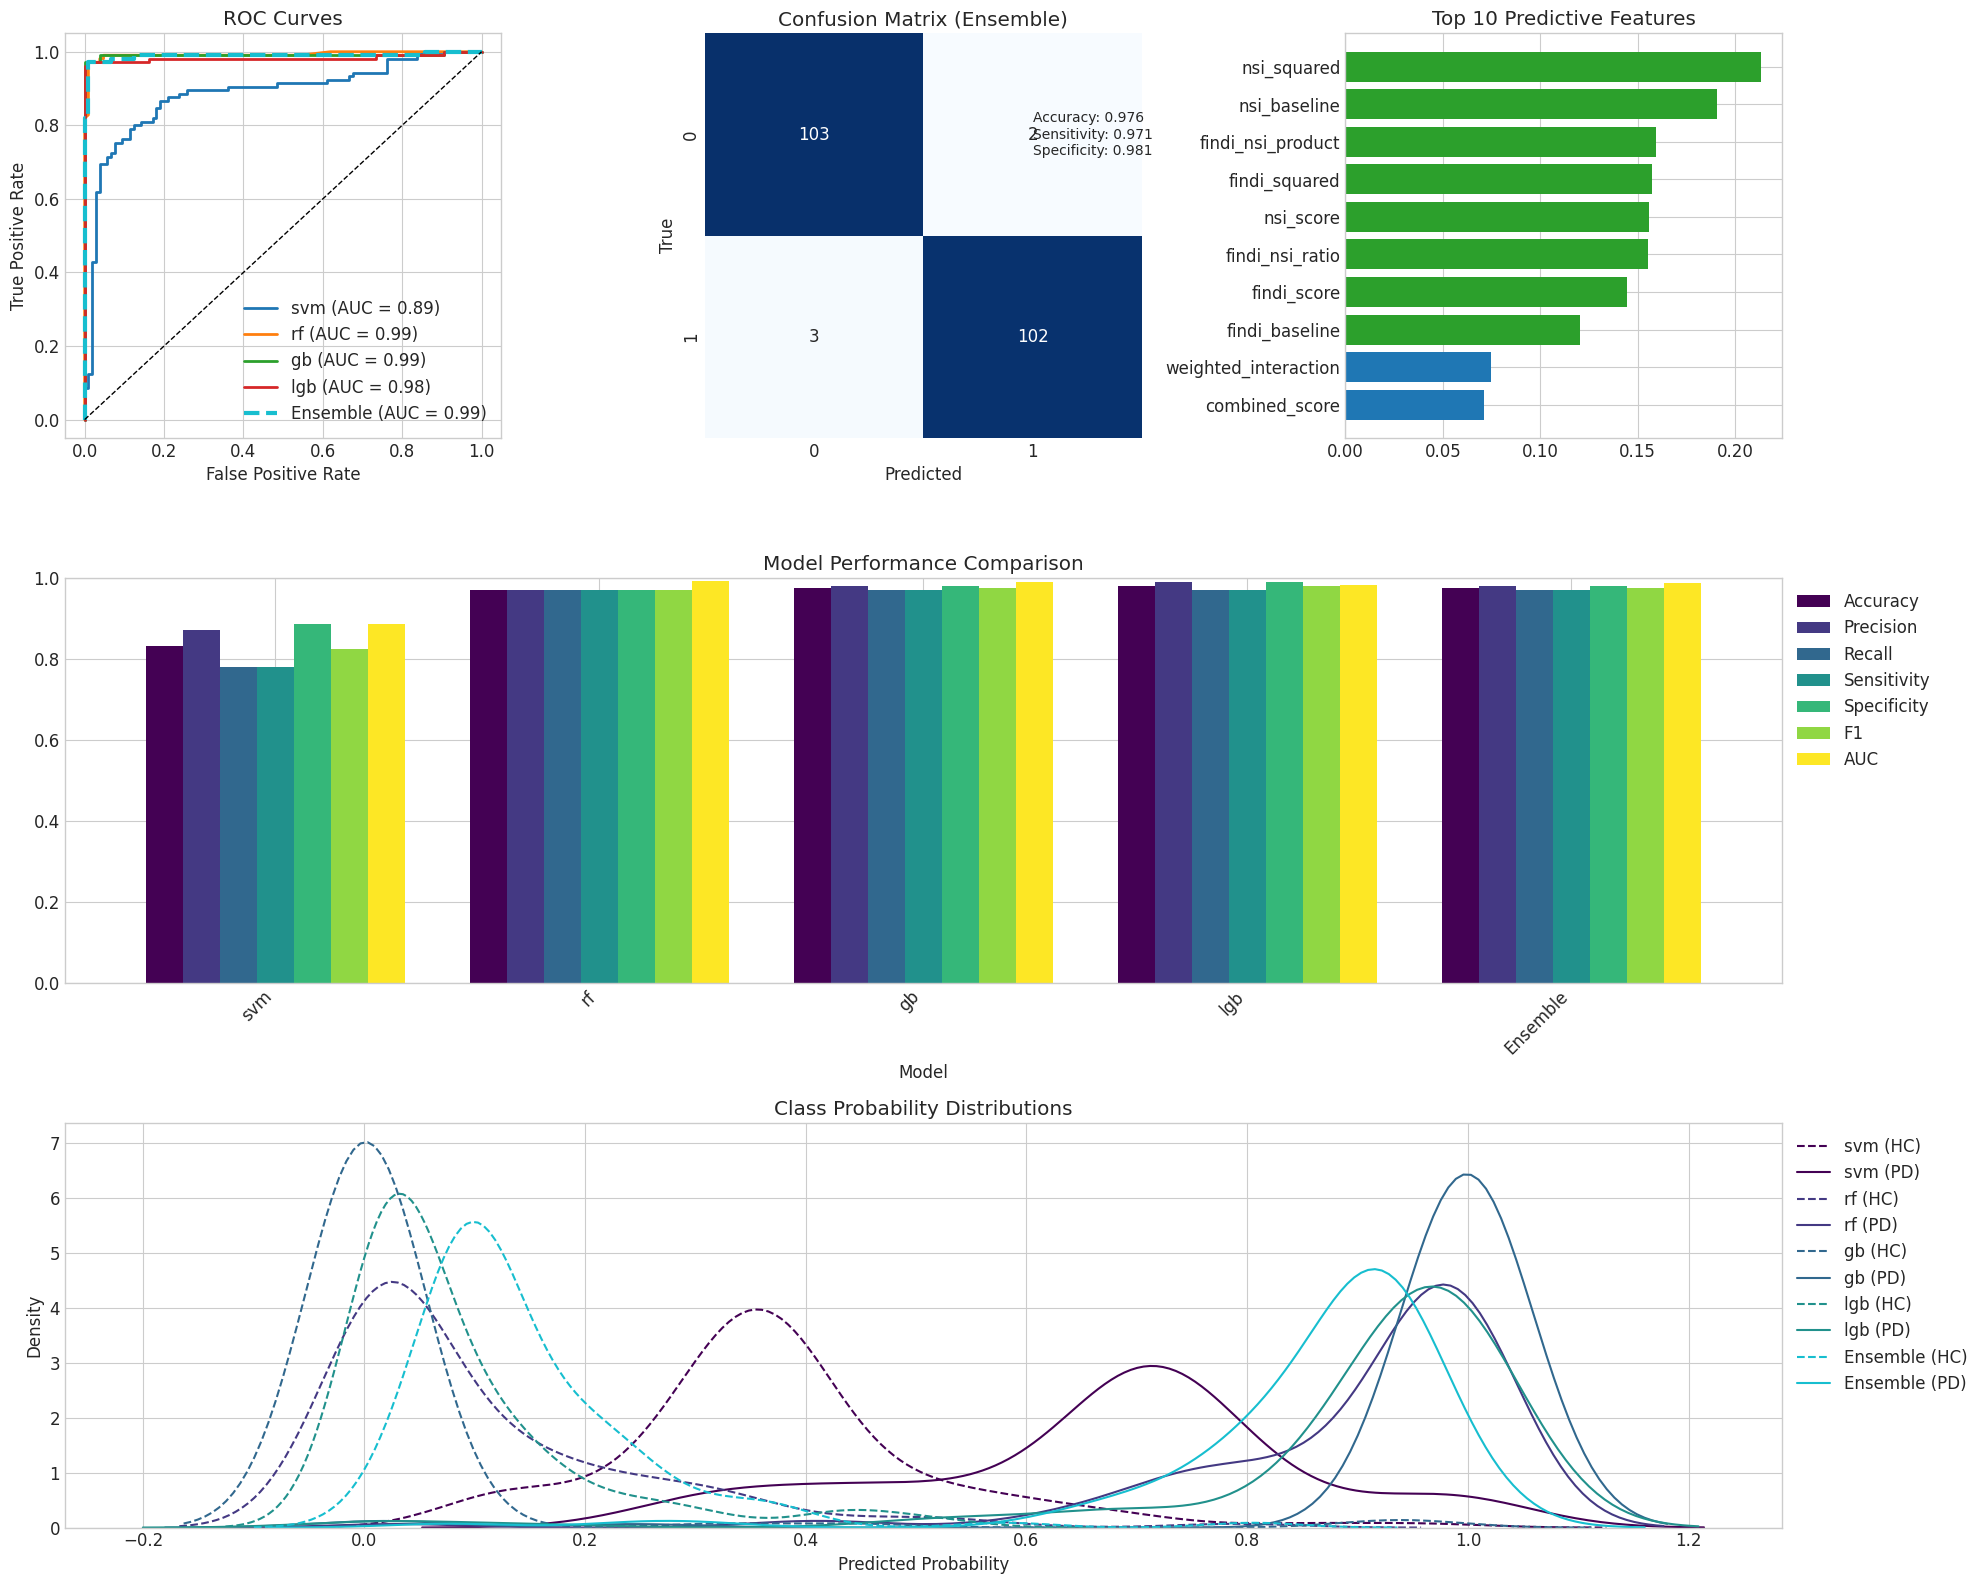


Saving the model...
Process completed successfully!


In [21]:
if __name__ == "__main__":
    # Load and preprocess data
    print("Loading and preprocessing data...")
    X, y = load_and_preprocess_data('/content/pd_biomarker_data.csv')

    try:
        # Create and optimize ensemble directly
        print("Starting model training and ensemble creation...")
        optimized_ensemble = optimize_hyperparameters(X, y)

        # Perform cross-validation
        print("\nPerforming cross-validation...")
        cv_scores = perform_cross_validation(optimized_ensemble, X, y)

        print("\nGenerating evaluation graphs...")
        plot_advanced_metrics(optimized_ensemble.models, X, y, optimized_ensemble)

        # Save the model
        print("\nSaving the model...")
        joblib.dump(optimized_ensemble, 'optimized_pd_classifier.joblib')
        print("Process completed successfully!")

    except Exception as e:
        print(f"An error occurred: {str(e)}")
        traceback.print_exc()